# 旋转矩形+grapcut前景扣图
## 鼠标绘制矩形、滚动条调整角度，按回车键开始扣图，可重复过程，按Esc退出

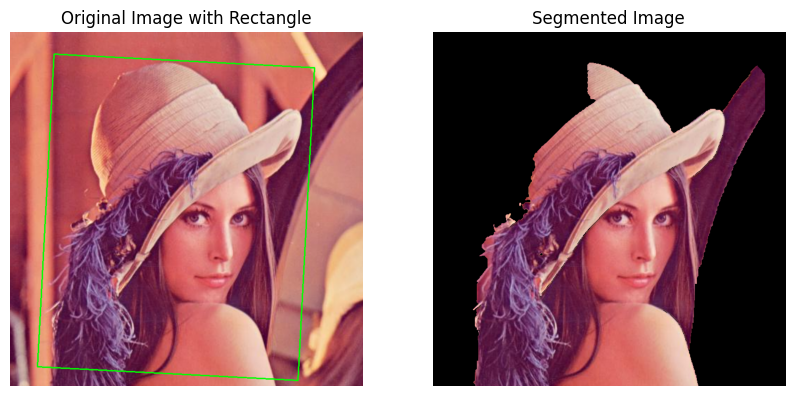

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 初始化全局变量
rect = (0, 0, 1, 1)
mask = None
grabcut_mode = 0
angle = 0  # 旋转角度

def mouse_callback(event, x, y, flags, param):
    global rect, grabcut_mode
    if event == cv2.EVENT_LBUTTONDOWN:
        rect = (x, y, x, y)
        grabcut_mode = 1
    elif event == cv2.EVENT_MOUSEMOVE:
        if grabcut_mode == 1:
            rect = (rect[0], rect[1], x, y)
    elif event == cv2.EVENT_LBUTTONUP:
        rect = (rect[0], rect[1], x, y)
        grabcut_mode = 0

def rotate_point(x, y, cx, cy, angle):
    angle_rad = np.deg2rad(angle)
    x -= cx
    y -= cy
    new_x = x * np.cos(angle_rad) - y * np.sin(angle_rad) + cx
    new_y = x * np.sin(angle_rad) + y * np.cos(angle_rad) + cy
    return int(new_x), int(new_y)

def rotate_rect(rect, angle, image_shape):
    cx, cy = (rect[0] + rect[2]) // 2, (rect[1] + rect[3]) // 2
    points = [
        (rect[0], rect[1]),
        (rect[2], rect[1]),
        (rect[2], rect[3]),
        (rect[0], rect[3])
    ]
    rotated_points = [rotate_point(x, y, cx, cy, angle) for x, y in points]
    rotated_points = np.array(rotated_points, dtype=np.int32)
    x, y, w, h = cv2.boundingRect(rotated_points)
    return (x, y, x + w, y + h), rotated_points

def grabcut_segmentation(image):
    global mask
    mask = np.zeros(image.shape[:2], np.uint8)
    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)
    
    if rect[2] > rect[0] and rect[3] > rect[1]:
        rotated_rect, _ = rotate_rect(rect, angle, image.shape)
        cv2.grabCut(image, mask, rotated_rect, bg_model, fg_model, 5, cv2.GC_INIT_WITH_RECT)
        
        mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
        result = image * mask2[:, :, np.newaxis]
        return result
    return image

def save_transparent_image(image, filename):
    b, g, r = cv2.split(image)
    rgba_image = cv2.merge((b, g, r, np.ones_like(b) * 255))
    cv2.imwrite(filename, rgba_image)

def update_angle(val):
    global angle
    angle = val

def main():
    global rect, mask, angle
    image = cv2.imread("input_image.jpg")
    clone = image.copy()

    cv2.namedWindow('Image')
    cv2.setMouseCallback('Image', mouse_callback)
    
    # 创建角度滑动条
    cv2.createTrackbar('Angle', 'Image', 0, 360, update_angle)

    while True:
        display = clone.copy()
        if rect[2] > rect[0] and rect[3] > rect[1]:
            _, rotated_points = rotate_rect(rect, angle, image.shape)
            cv2.polylines(display, [rotated_points], isClosed=True, color=(0, 255, 0), thickness=2)
        
        cv2.imshow('Image', display)

        key = cv2.waitKey(1) & 0xFF
        if key == 13:  # Enter key
            segmented = grabcut_segmentation(image)

            # 使用matplotlib显示图像
            plt.figure(figsize=(10, 5))
            
            # 带矩形的原图
            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
            plt.title("Original Image with Rectangle")
            plt.axis('off')
            
            # 扣图后的图像
            plt.subplot(1, 2, 2)
            plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
            plt.title("Segmented Image")
            plt.axis('off')
            
            plt.show()

            # 使用cv2.imshow显示扣图后的图像
            cv2.imshow('Segmented', segmented)

        elif key == 27:  # ESC key
            if 'segmented' in locals():
                save_transparent_image(segmented, 'output_image.png')
            break

    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


# 手绘mask+前后景扣图
## 注：左键绘制前景，右键绘制后景，点击g键开始抠图，可重复直至完美。点击q退出。

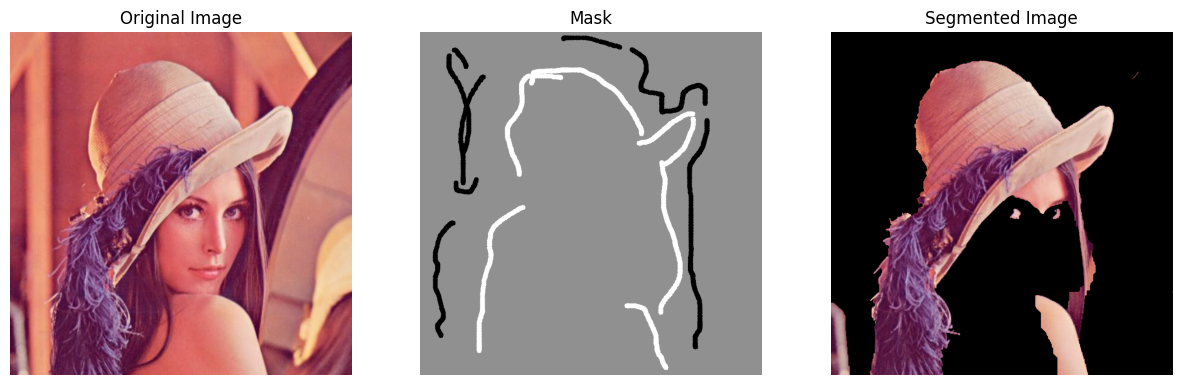

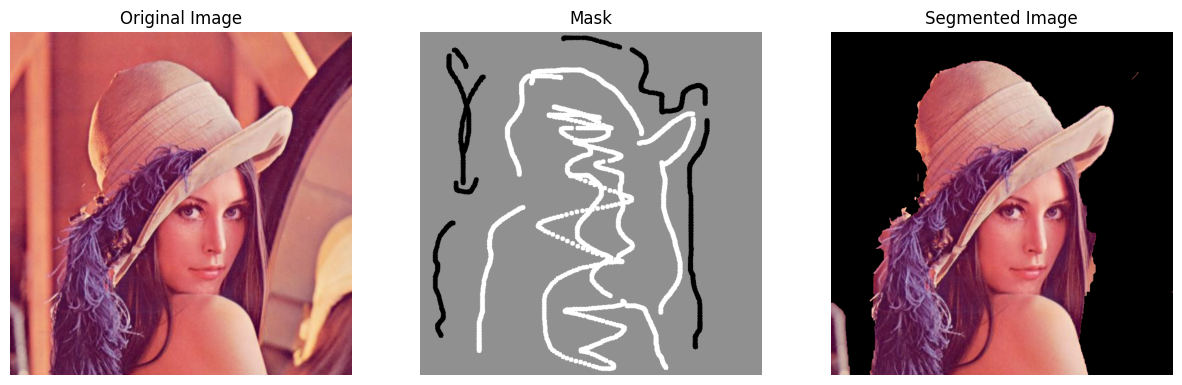

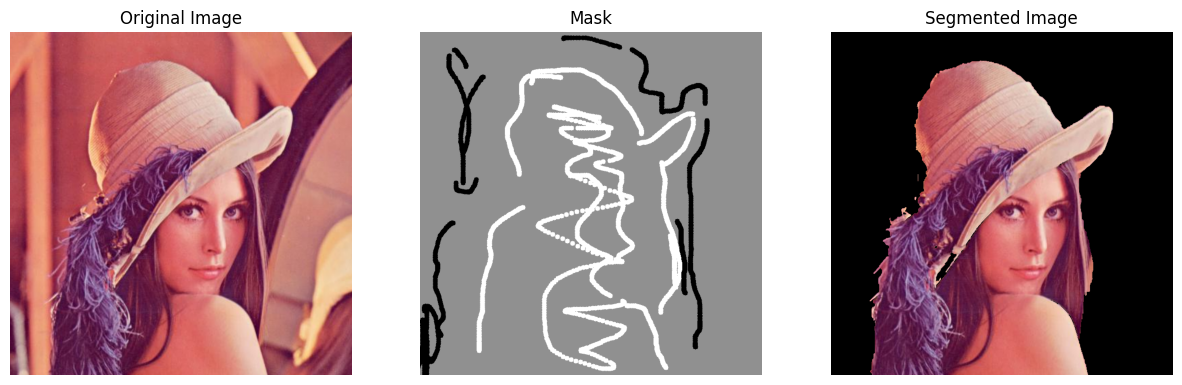

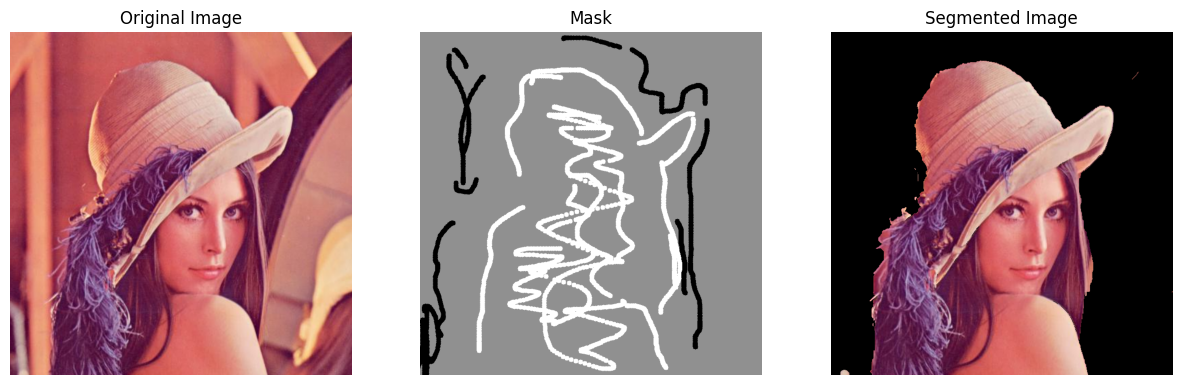

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 初始化mask
mask = None
drawing = False  # true if mouse is pressed
current_mode = None  # Current drawing mode (foreground, background, probable background)

# 鼠标回调函数
def onmouse(event, x, y, flags, param):
    global drawing, mask, current_mode

    # 根据鼠标按钮选择模式
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        current_mode = 255  # 白色, 确定前景
    elif event == cv2.EVENT_RBUTTONDOWN:
        drawing = True
        current_mode = 0  # 黑色, 确定背景
    elif event == cv2.EVENT_MBUTTONDOWN:
        drawing = True
        current_mode = 144  # 灰色, 可能背景

    # 鼠标移动，绘制mask
    if drawing and event == cv2.EVENT_MOUSEMOVE:
        cv2.circle(mask, (x, y), 5, current_mode, -1)

    # 鼠标释放，停止绘制
    elif event in (cv2.EVENT_LBUTTONUP, cv2.EVENT_RBUTTONUP, cv2.EVENT_MBUTTONUP):
        drawing = False
        cv2.circle(mask, (x, y), 5, current_mode, -1)

# 加载图片
img = cv2.imread('input_image.jpg')
if img is None:
    print("Image not loaded properly")
    exit()

# 初始化mask为灰色
mask = np.full(img.shape[:2], 144, dtype=np.uint8)

# 创建一个窗口并绑定鼠标回调函数
cv2.namedWindow('input')
cv2.setMouseCallback('input', onmouse)

# 使用GrabCut算法
while(1):
    cv2.imshow('input', img)
    cv2.imshow('mask', mask)
    k = cv2.waitKey(1)

    # 按下'g'键进行GrabCut
    if k == ord('g'):
        bgdmodel = np.zeros((1, 65), np.float64)
        fgdmodel = np.zeros((1, 65), np.float64)
        # 准备适用于grabCut的mask，将用户自定义颜色转化为grabCut接受的形式
        grabcut_mask = np.where(mask == 255, 1, np.where(mask == 144, 2, 0)).astype('uint8')
        cv2.grabCut(img, grabcut_mask, None, bgdmodel, fgdmodel, 5, cv2.GC_INIT_WITH_MASK)
        mask2 = np.where((grabcut_mask == 2) | (grabcut_mask == 0), 0, 1).astype('uint8')
        img_display = img * mask2[:, :, np.newaxis]

        # 使用matplotlib显示图像
        plt.figure(figsize=(15, 5))
        
        # 显示原图
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original Image")
        plt.axis('off')
        
        # 显示mask
        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap='gray')
        plt.title("Mask")
        plt.axis('off')
        
        # 显示扣图后的图像
        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
        plt.title("Segmented Image")
        plt.axis('off')
        
        plt.show()
    
    # 按下'q'键退出
    elif k == ord('q'):
        break

cv2.destroyAllWindows()


# 证件照制作
## 每次调整完滚动条要按下g键背景颜色才会变换

In [4]:
import cv2
import numpy as np

# 初始化mask
mask = None
drawing = False  # True if mouse is pressed
current_mode = None  # Current drawing mode (foreground, background, probable background)
bg_color = [255, 255, 255]  # 初始背景颜色为白色

# 鼠标回调函数
def onmouse(event, x, y, flags, param):
    global drawing, mask, current_mode

    # 根据鼠标按钮选择模式
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        current_mode = 255  # 确定前景
    elif event == cv2.EVENT_RBUTTONDOWN:
        drawing = True
        current_mode = 0  # 确定背景
    elif event == cv2.EVENT_MBUTTONDOWN:
        drawing = True
        current_mode = 144  # 可能背景

    # 鼠标移动，绘制mask
    if drawing and event == cv2.EVENT_MOUSEMOVE:
        cv2.circle(mask, (x, y), 5, current_mode, -1)

    # 鼠标释放，停止绘制
    elif event in (cv2.EVENT_LBUTTONUP, cv2.EVENT_RBUTTONUP, cv2.EVENT_MBUTTONUP):
        drawing = False
        cv2.circle(mask, (x, y), 5, current_mode, -1)

# 加载图片
img = cv2.imread('input_image.jpg')
if img is None:
    print("Image not loaded properly")
    exit()

# 初始化mask为灰色
mask = np.full(img.shape[:2], 144, dtype=np.uint8)

# 创建一个窗口并绑定鼠标回调函数
cv2.namedWindow('input')
cv2.setMouseCallback('input', onmouse)

# 创建显示结果的窗口和背景颜色的滚动条
cv2.namedWindow('output')
cv2.createTrackbar('R', 'output', 255, 255, lambda x: None)
cv2.createTrackbar('G', 'output', 255, 255, lambda x: None)
cv2.createTrackbar('B', 'output', 255, 255, lambda x: None)

# 使用GrabCut算法
while True:
    cv2.imshow('input', img)
    cv2.imshow('mask', mask)
    k = cv2.waitKey(1)

    # 按下'g'键进行GrabCut
    if k == ord('g'):
        bgdmodel = np.zeros((1, 65), np.float64)
        fgdmodel = np.zeros((1, 65), np.float64)
        # 准备适用于grabCut的mask，将用户自定义颜色转化为grabCut接受的形式
        grabcut_mask = np.where(mask == 255, 1, np.where(mask == 144, 2, 0)).astype('uint8')
        cv2.grabCut(img, grabcut_mask, None, bgdmodel, fgdmodel, 5, cv2.GC_INIT_WITH_MASK)
        mask2 = np.where((grabcut_mask == 2) | (grabcut_mask == 0), 0, 1).astype('uint8')
        img_display = img * mask2[:, :, np.newaxis]

        # 实时获取滚动条的值来更新背景颜色
        r = cv2.getTrackbarPos('R', 'output')
        g = cv2.getTrackbarPos('G', 'output')
        b = cv2.getTrackbarPos('B', 'output')
        bg_color = [b, g, r]  # 注意OpenCV的颜色顺序是BGR

        # 创建背景颜色图像
        bg_image = np.full_like(img_display, bg_color, dtype=np.uint8)
        img_output = np.where(mask2[:, :, np.newaxis] == 1, img_display, bg_image)

        cv2.imshow('output', img_output)

    # 按下'q'键退出
    elif k == ord('q'):
        break

cv2.destroyAllWindows()


# 图像标注工具

In [2]:
import cv2
import os

DATA_DIR = "./images/"
LABEL_DIR = "./label_img/"
IM_ROWS = 1  
IM_COLS = 6  

ptL, ptR = (0, 0), (0, 0)  # 鼠标画出矩形框的起点和终点
drawing = False  # 是否正在绘制矩形
rectangles = []  # 存储所有矩形框


def on_mouse(event, x, y, flags, param):
    global ptL, ptR, drawing, rectangles, image_source_copy

    if event == cv2.EVENT_LBUTTONDOWN:
        ptL = (x, y)
        ptR = (x, y)
        drawing = True
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            ptR = (x, y)
            image_source_copy = image_source.copy()
            cv2.rectangle(image_source_copy, ptL, ptR, (0, 255, 0), 2)
            cv2.imshow("Labeling", image_source_copy)
    elif event == cv2.EVENT_LBUTTONUP:
        if ptL != ptR:
            ptR = (x, y)
            cv2.rectangle(image_source_copy, ptL, ptR, (0, 255, 0), 2)
            cv2.imshow("Labeling", image_source_copy)

            x1, y1 = ptL
            x2, y2 = ptR
            w = x2 - x1
            h = y2 - y1

            print(f"Selected region: x:{x1} y:{y1} w:{w} h:{h}")
            rectangles.append((x1, y1, w, h))
            drawing = False


def draw_area(src, img_name, path_name):
    global image_source, image_source_copy, rectangles

    image_source = src.copy()
    image_source_copy = src.copy()
    rectangles = []

    height, width = src.shape[:2]

    cv2.namedWindow("Labeling")
    cv2.setMouseCallback("Labeling", on_mouse)

    while True:
        cv2.imshow("Labeling", image_source_copy)
        key = cv2.waitKey(0) & 0xFF

        if key == ord('y'):  # 按 'y' 确认标注
            print(f"Number of rectangles: {len(rectangles)}")
            with open('record.txt', 'a+') as fp_result:
                fp_result.write(f"{img_name}\n")
                for (x, y, w, h) in rectangles:
                    # 归一化坐标
                    x_norm = x / width
                    y_norm = y / height
                    w_norm = w / width
                    h_norm = h / height
                    fp_result.write(f"{x_norm:.6f} {y_norm:.6f} {w_norm:.6f} {h_norm:.6f}\n")
                print("矩形信息保存成功")
            rectangles = []  # 清空矩形框
            image_source_copy = image_source.copy()  # 清空显示上的矩形
        elif key == 13:  # Enter键切换到下一张图像
            break
        elif key == 27:  # ESC键退出
            cv2.destroyAllWindows()
            exit()


def main():
    start_i, start_j = 0, 0
    try:
        with open("start.txt", "r") as fp:
            content = fp.read().strip().split()
            if len(content) != 2:
                raise ValueError("start.txt 文件中应包含两个整数，用空格分隔。")
            start_i, start_j = map(int, content)
    except ValueError as e:
        print(f"读取 start.txt 文件时出错: {e}")
        return
    except FileNotFoundError:
        print("找不到 start.txt 文件。")
        return

    print(f"start_i: {start_i}, start_j: {start_j}")

    for i in range(start_i, IM_ROWS):
        for j in range(start_j, IM_COLS):
            img_name = f"{DATA_DIR}{j+1}.jpg"
            label_img_name = f"{LABEL_DIR}{j+1}_label.jpg"
            print(img_name)
            src = cv2.imread(img_name)

            if src is not None:
                draw_area(src, img_name, label_img_name)
            else:
                print(f"无法读取图像: {img_name}")

            # 在每张图像标注完成后，按下 Enter 键切换到下一张图像
            while True:
                key = cv2.waitKey(0) & 0xFF
                if key == 13:  # Enter键
                    break
                elif key == 27:  # ESC键退出
                    cv2.destroyAllWindows()
                    exit()

    print("所有图像处理完毕。")
    cv2.destroyAllWindows()  # 关闭所有打开的窗口


if __name__ == "__main__":
    main()


start_i: 0, start_j: 0
./images/1.jpg
Selected region: x:287 y:194 w:173 h:148
Number of rectangles: 1
矩形信息保存成功
Selected region: x:301 y:208 w:184 h:177
Selected region: x:167 y:292 w:214 h:204
Selected region: x:334 y:200 w:148 h:162
Number of rectangles: 3
矩形信息保存成功
./images/2.jpg
Selected region: x:434 y:449 w:132 h:246
./images/3.jpg
Selected region: x:320 y:488 w:229 h:188
./images/4.jpg
./images/5.jpg
./images/6.jpg
所有图像处理完毕。
